In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report

In [9]:
print("\nLoading Dataset...") 
dataset = pd.read_csv("spam.csv", encoding="latin1") 
print("Dataset Loaded Successfully")


Loading Dataset...
Dataset Loaded Successfully


In [11]:
print("\n First Five Records")
print(dataset.head())


 First Five Records
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [12]:
print("\n Dataset Information")
dataset.info()
print("\n Dataset Shape")
print(dataset.shape)


 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

 Dataset Shape
(5572, 2)


In [13]:
print("\n Missing values")
print(dataset.isnull().sum())


 Missing values
Category    0
Message     0
dtype: int64


In [16]:
print("\n Email category count")
print(dataset["Category"].value_counts())


 Email category count
Category
ham     4825
spam     747
Name: count, dtype: int64


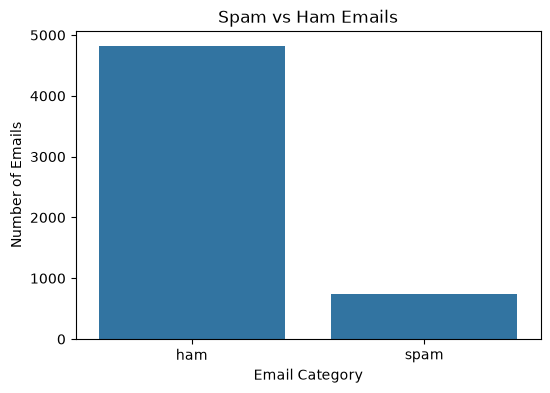

In [17]:
plt.figure(figsize=(6,4)) 
sns.countplot(x="Category",data=dataset) 
plt.title("Spam vs Ham Emails") 
plt.xlabel("Email Category") 
plt.ylabel("Number of Emails") 
plt.show() 

In [18]:
X = dataset["Message"] 
y = dataset["Category"] 

In [19]:
X_train,X_test,y_train,y_test = train_test_split( 
X, 
y, 
test_size=0.20, 
random_state=42 
) 
print("\nTraining Samples :",len(X_train)) 
print("Testing Samples  :",len(X_test))


Training Samples : 4457
Testing Samples  : 1115


In [22]:
print("\n converting text into numerical features...")
cv=CountVectorizer()
X_train=cv.fit_transform(X_train)
X_test=cv.transform(X_test)
print("conversion completed")
print("training data shape:",X_train.shape)
print("testing data shape:",X_test.shape)


 converting text into numerical features...
conversion completed
training data shape: (4457, 7733)
testing data shape: (1115, 7733)


In [24]:
print("\n training svm model...")
Classifier=SVC(kernel="linear")
Classifier.fit(X_train,y_train)
print("model trainning completed")


 training svm model...
model trainning completed


In [28]:
print("\nPredicting Test Data...") 
y_pred = Classifier.predict(X_test) 
print("Prediction Completed") 


Predicting Test Data...
Prediction Completed


In [30]:
accuracy=accuracy_score(y_test,y_pred)
print("MODEL ACCURACY")
print("Accuracy=",accuracy)
print("Accuracy={:2f}%",format(accuracy*100))

MODEL ACCURACY
Accuracy= 0.989237668161435
Accuracy={:2f}% 98.9237668161435



 confusion Matrix
[[966   0]
 [ 12 137]]


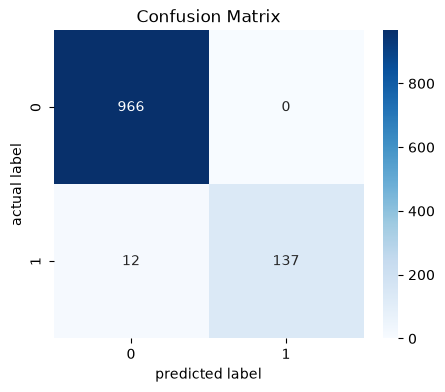

In [33]:
cm=confusion_matrix(y_test,y_pred)
print("\n confusion Matrix")
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.title("Confusion Matrix")
plt.show()

In [35]:
print("\n classification report")
print(classification_report(y_test,y_pred))


 classification report
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.92      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [37]:
print("Sample Predictions")
sample_messages=[
    "congratulation! you have won a free iphone.click here to claim.",
    "Hi,Shall we meet tomorrow at 10 AM?",
    "URGENT! your bank account has been suspended verify immediately.",
    "Happy Birthday! Have a wonderfull day.",
    "You have won Rs.50000 cash prize.call now."
]
sample_data=cv.transform(sample_messages)
predictions=Classifier.predict(sample_data)
for message,prediction in zip (sample_messages,predictions):
    print("\n message:")
    print(message)
    print("prediction:", prediction)

Sample Predictions

 message:
congratulation! you have won a free iphone.click here to claim.
prediction: spam

 message:
Hi,Shall we meet tomorrow at 10 AM?
prediction: ham

 message:
URGENT! your bank account has been suspended verify immediately.
prediction: spam

 message:
Happy Birthday! Have a wonderfull day.
prediction: ham

 message:
You have won Rs.50000 cash prize.call now.
prediction: spam
